# Eksperimen Q-Learning Scenario B

State: `(current_node, progress_bin)` — agen mengetahui node dan kategori progres jarak.

Notebook ini tidak menduplikasi implementasi. Semua konfigurasi, download/load OSM, environment, reward, Q-Learning, metrik, grafik, dan peta berasal dari `rute_lari_core.py`.

In [10]:
%pip install -q "osmnx>=2.0" networkx numpy pandas geopandas shapely folium matplotlib pyproj

Note: you may need to restart the kernel to use updated packages.


## 1. Muat graf dengan core bersama

Jika GraphML belum ada, fungsi berikut mengunduh data OSM dengan konfigurasi yang sama seperti notebook analisis. Jika sudah ada, GraphML dimuat tanpa mengunduh ulang.

In [13]:
import importlib
import rute_lari_core

# Memuat ulang core agar perubahan grafik terbaru terbaca tanpa restart kernel.
importlib.reload(rute_lari_core)

from rute_lari_core import (
    load_or_download_graph,
    run_scenario_experiment,
    EPISODES,
    SEEDS,
)

G, START_NODE, GRAPH_PATH, downloaded_now = load_or_download_graph()

print(f'Graf: {G.number_of_nodes():,} node, {G.number_of_edges():,} edge')
print(f'Node start: {START_NODE}')
print(f'GraphML: {GRAPH_PATH}')
print('Sumber graf:', 'download baru' if downloaded_now else 'GraphML yang sudah ada')
print(f'Training: {len(SEEDS)} seed × {EPISODES:,} episode')

Graf: 8,027 node, 21,374 edge
Node start: 1720975931
GraphML: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/data_osm_5km/graf_jalan_kaki_5km.graphml
Sumber graf: GraphML yang sudah ada
Training: 5 seed × 2,500 episode


## 2. Jalankan training dan evaluasi

Cell ini menjalankan satu scenario saja. Hasil visual yang ditampilkan mencakup grafik training utama, grafik diagnosis selama training, grafik termination rate dengan legenda lima tipe terminasi, dan peta rute interaktif. Data mentah tetap disimpan sebagai CSV.

Menjalankan Scenario B: 5 seed x 2,500 episode
seed=0: no_available_action, 4.73 km, is_loop=False
seed=1: over_distance, 5.61 km, is_loop=False
seed=2: no_available_action, 3.60 km, is_loop=False
seed=3: no_available_action, 4.01 km, is_loop=False
seed=4: no_available_action, 5.33 km, is_loop=False
Metrik evaluasi greedy per seed (semua kolom)


,is_loop,termination_reason,distance_m,distance_km,absolute_distance_error_m,overshoot_m,distance_to_start_at_end_m,return_progress_ratio,return_phase_steps,return_progress_steps,closing_action_was_available,steps,total_reward,mean_comfort,revisit_count,repeated_intermediate_nodes,unique_edge_ratio,scenario,seed,q_state_count,q_action_entry_count,training_seconds
0,False,no_available_action,4733.425236,4.733425,266.574764,0.000000,740.062477,0.689655,29,20,False,55,-72.472413,0.779517,5,5,0.963636,B,0,6945,12022,1.145811
1,False,over_distance,5611.382575,5.611383,611.382575,111.382575,709.066820,0.619048,42,26,False,68,-104.194891,0.676402,8,8,0.970588,B,1,7091,12068,1.169909
2,False,no_available_action,3601.388119,3.601388,1398.611881,0.000000,1183.696563,0.421053,19,8,False,57,-84.976643,0.740444,6,5,0.982456,B,2,6754,11411,1.137844
3,False,no_available_action,4010.348654,4.010349,989.651346,0.000000,1393.748305,0.357143,14,5,False,40,-70.778518,0.709200,4,4,0.975000,B,3,7078,11982,1.167960
4,False,no_available_action,5326.350079,5.326350,326.350079,0.000000,797.143577,0.525000,40,21,False,67,-80.878647,0.723476,6,6,0.955224,B,4,6986,12016,1.166428


Tampilan vertikal metrik evaluasi per seed


seed,0,1,2,3,4
is_loop,False,False,False,False,False
termination_reason,no_available_action,over_distance,no_available_action,no_available_action,no_available_action
distance_m,4733.425236,5611.382575,3601.388119,4010.348654,5326.350079
distance_km,4.733425,5.611383,3.601388,4.010349,5.32635
absolute_distance_error_m,266.574764,611.382575,1398.611881,989.651346,326.350079
overshoot_m,0.0,111.382575,0.0,0.0,0.0
distance_to_start_at_end_m,740.062477,709.06682,1183.696563,1393.748305,797.143577
return_progress_ratio,0.689655,0.619048,0.421053,0.357143,0.525
return_phase_steps,29,42,19,14,40
return_progress_steps,20,26,8,5,21


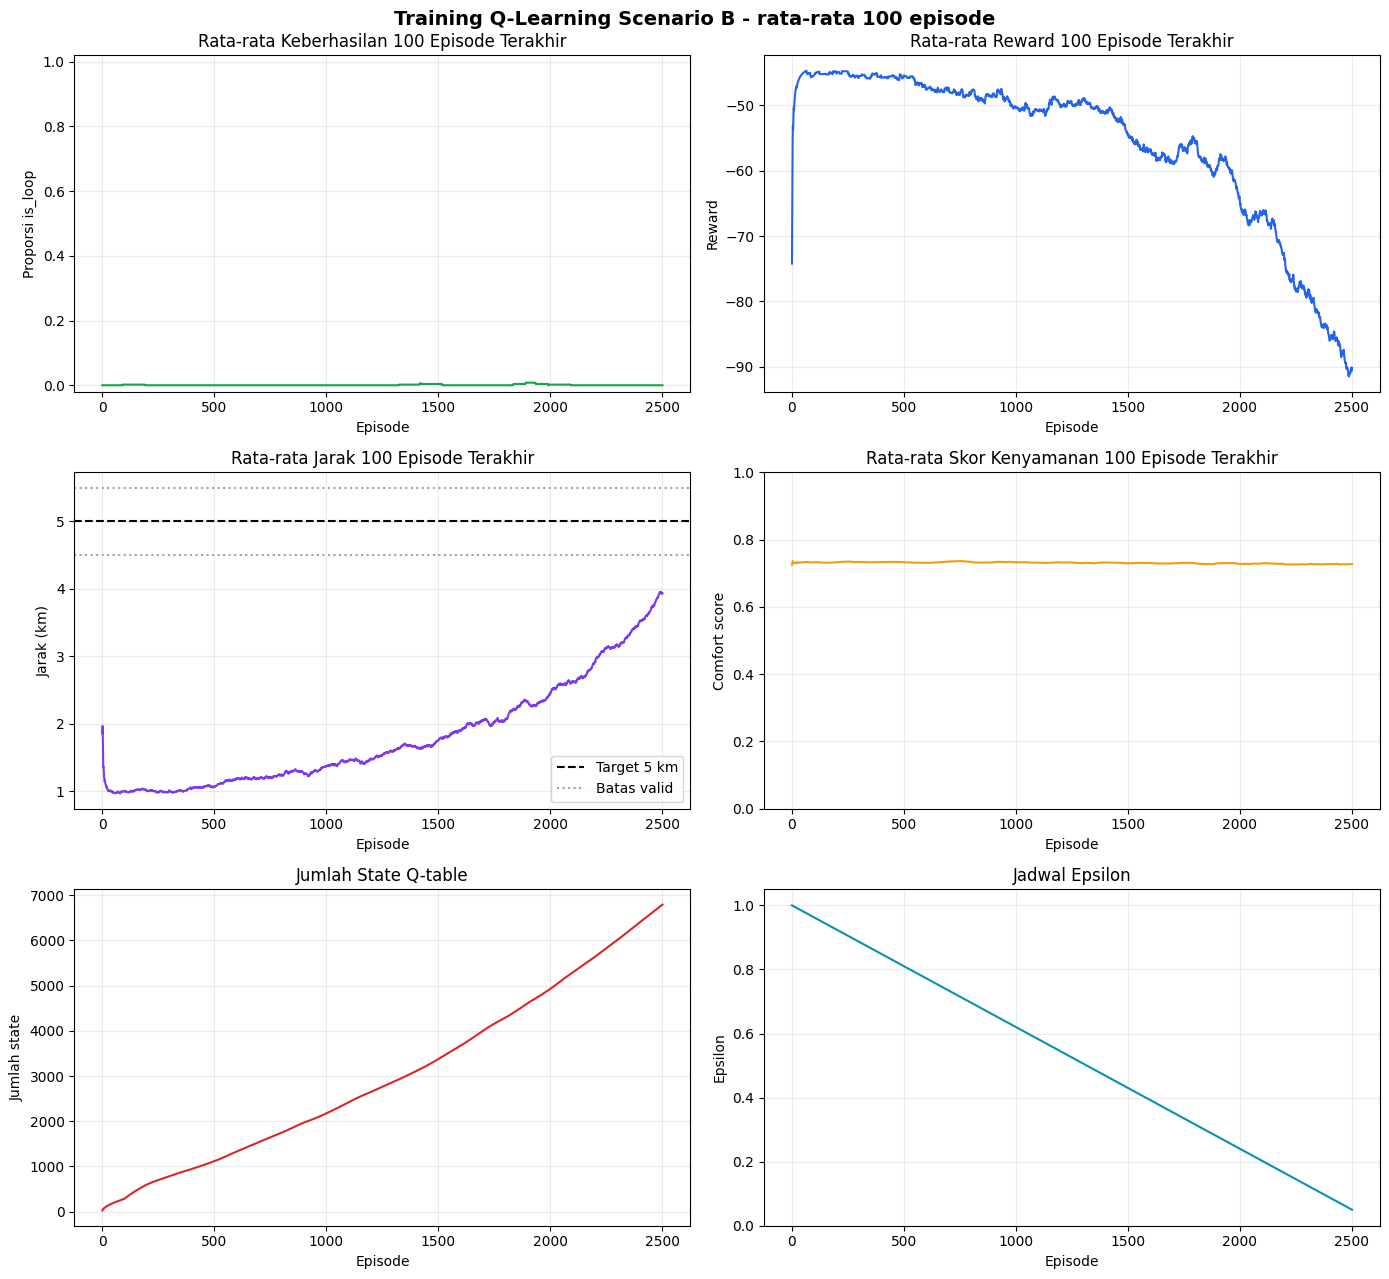

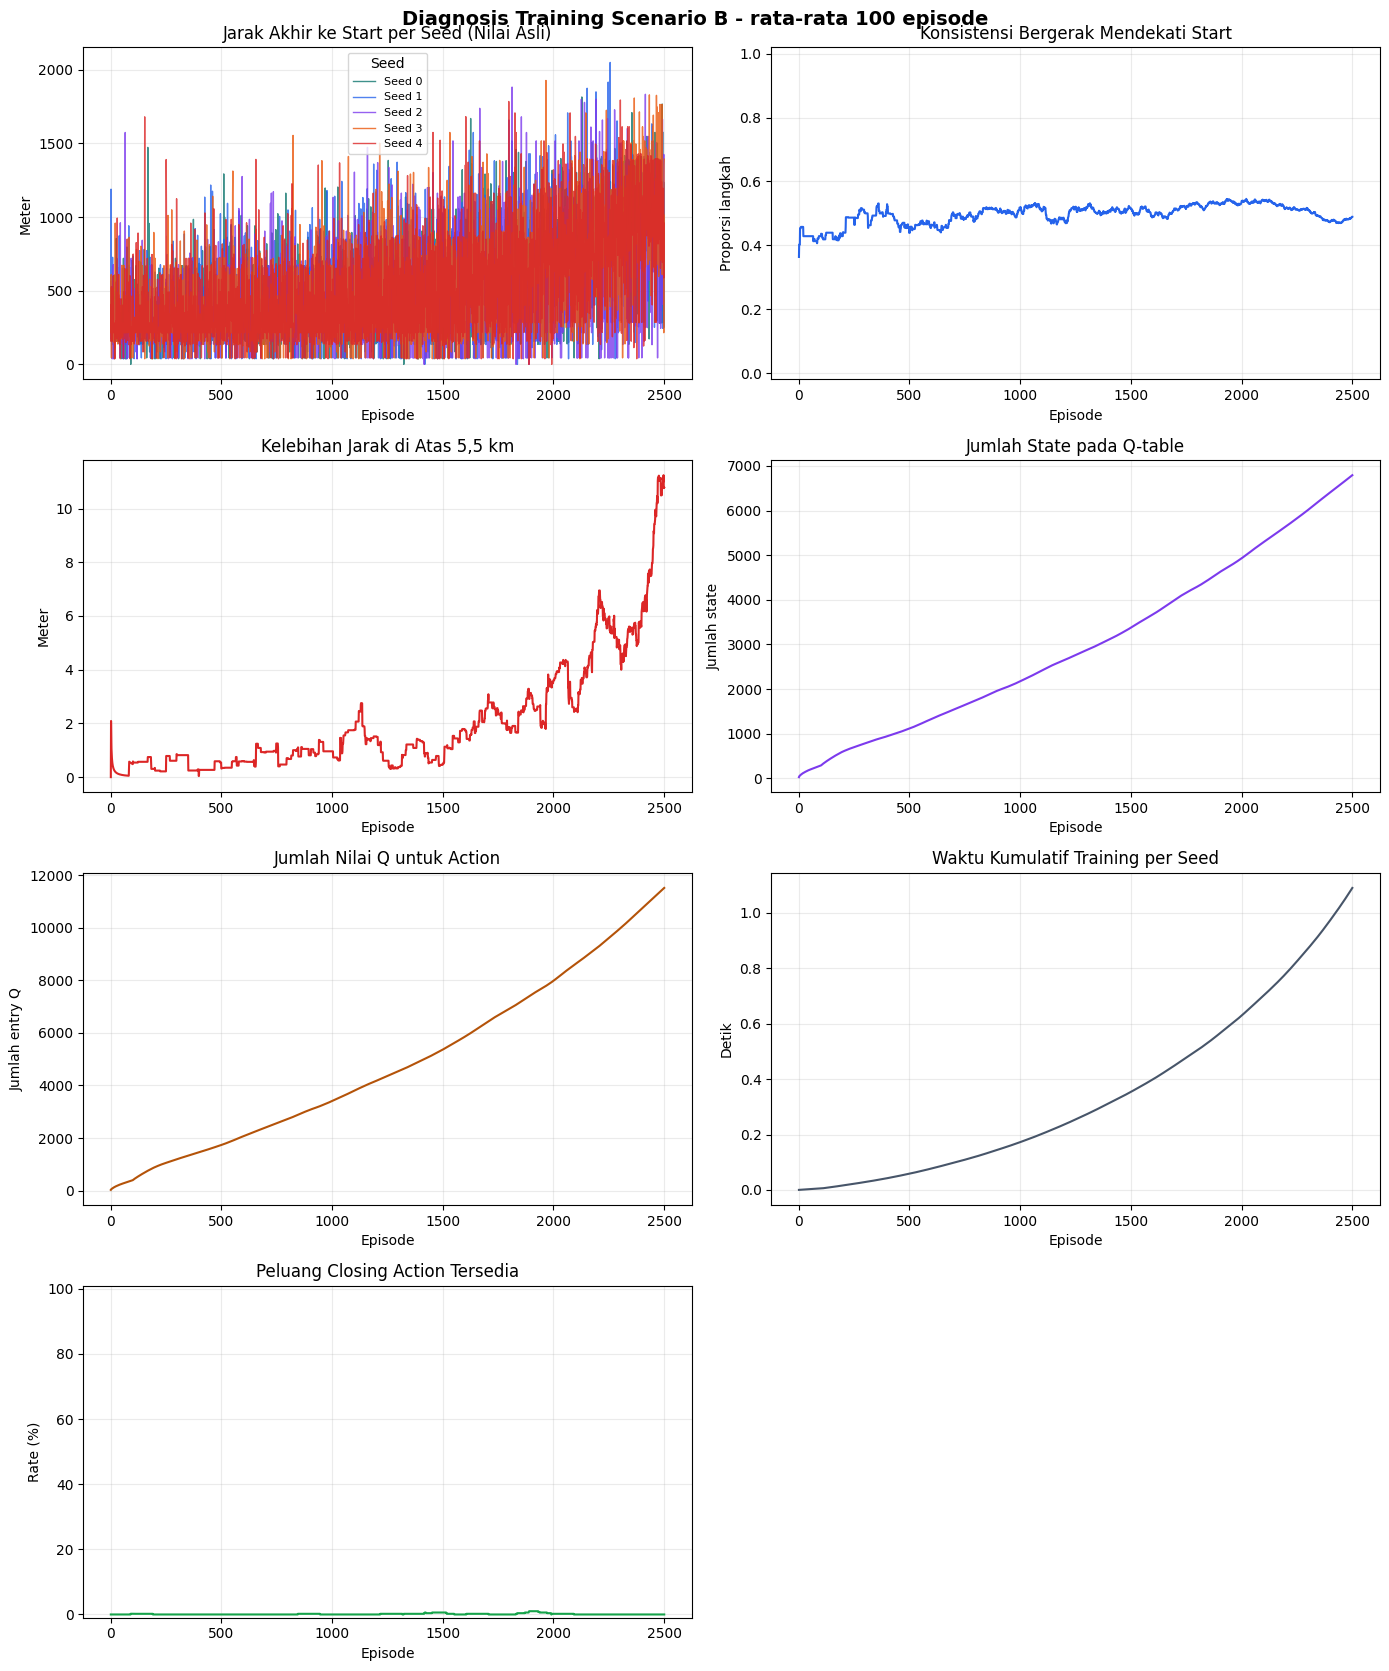

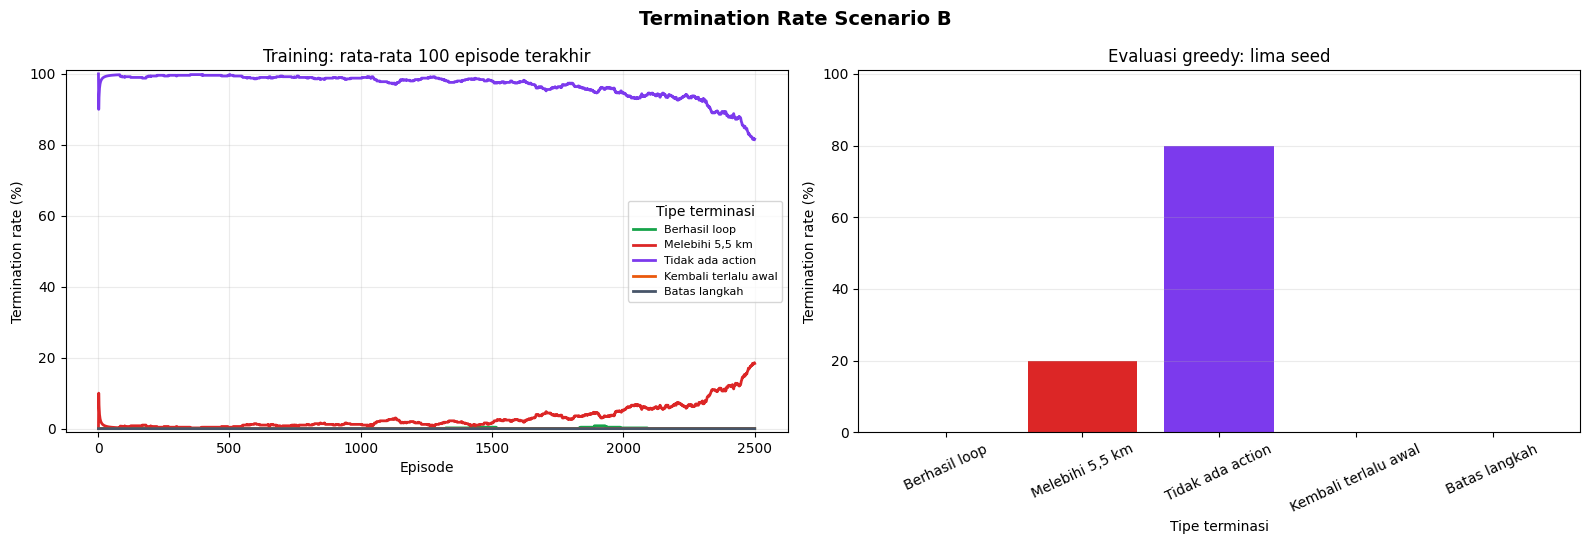

History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/training_history_B.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/evaluation_metrics_B.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/diagnosis_metrics_B.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/termination_rates_training_B.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/termination_rates_evaluation_B.csv
Grafik training utama: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/grafik_training_B.png
Grafik diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/t

In [14]:
# Reload juga di cell ini agar aman bila cell training dijalankan ulang sendiri.
importlib.reload(rute_lari_core)
result_b = rute_lari_core.run_scenario_experiment(G, START_NODE, 'B')

## 3. Metrik diagnosis yang perlu dibaca

- `distance_to_start_at_end_m`: jarak lurus dari posisi akhir ke start.
- `return_progress_ratio`: proporsi langkah setelah 2,75 km yang membuat agen mendekati start.
- `termination_rate`: proporsi seed yang berakhir pada `success`, `over_distance`, `no_available_action`, `early_return`, atau `step_limit`.

Baca detail seluruh implementasi di `IMPLEMENTASI.md`.